In [1]:
import sys
from pathlib import Path

# Ensure project root is importable when notebook runs from notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: d:\Projet\scanned_images_classifier


# OCR Fine-tuning CPU (batch_1 -> batch_2)

Ce notebook entraine un modele OCR image->texte sur `batch_1` avec les annotations CSV (`batch1_1` + `batch1_3`) et evalue sur `batch1_2`, puis teste l'inference sur `batch_2`.


In [2]:
from pathlib import Path
import json

from src.ocr_image_text.config import TrainConfig, InferConfig
from src.ocr_image_text.data import resolve_default_data_root, load_multi_ocr_sources, load_images_from_subdirs
from src.ocr_image_text.train import run_training
from src.ocr_image_text.inference import load_predictor
from src.ocr_image_text.evaluation import evaluate_records


In [3]:
data_root = resolve_default_data_root()

# Force artifacts in notebooks/artifacts to avoid loading stale smoke models from ./artifacts
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
output_dir = (repo_root / "notebooks" / "artifacts" / "doc_understanding_ocr_cpu").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

legacy_output_dir = (repo_root / "artifacts" / "doc_understanding_ocr_cpu").resolve()
if legacy_output_dir.exists() and legacy_output_dir != output_dir:
    print(f"[info] Ignoring legacy artifacts at: {legacy_output_dir}")

print("data_root:", data_root)
print("output_dir (forced):", output_dir)


[info] Ignoring legacy artifacts at: D:\Projet\scanned_images_classifier\artifacts\doc_understanding_ocr_cpu
data_root: C:\Users\Francis BACKELAND\.cache\kagglehub\datasets\osamahosamabdellatif\high-quality-invoice-images-for-ocr\versions\3
output_dir (forced): D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu


In [4]:
train_csvs = (
    "batch_1/batch_1/batch1_1.csv",
    "batch_1/batch_1/batch1_2.csv",
    "batch_1/batch_1/batch1_3.csv",
)
train_image_subdirs = (
    "batch_1/batch_1/batch1_1",
    "batch_1/batch_1/batch1_2",
    "batch_1/batch_1/batch1_3",
)
val_image_subdirs = (
    "batch_2/batch_2/batch2_1",
    "batch_2/batch_2/batch2_2",
    "batch_2/batch_2/batch2_3",
)

train_records = load_multi_ocr_sources(
    data_root=data_root,
    csv_paths=train_csvs,
    image_subdirs=train_image_subdirs,
)
val_image_paths = load_images_from_subdirs(data_root, val_image_subdirs)

print("num_train_records:", len(train_records))
print("num_val_images_batch2:", len(val_image_paths))
print("sample_train_image:", train_records[0].image_path)
print("sample_train_text[:200]:", train_records[0].ocr_text[:200])
if val_image_paths:
    print("sample_val_image:", val_image_paths[0])


num_train_records: 1413
num_val_images_batch2: 1491
sample_train_image: C:\Users\Francis BACKELAND\.cache\kagglehub\datasets\osamahosamabdellatif\high-quality-invoice-images-for-ocr\versions\3\batch_1\batch_1\batch1_1\batch1-0494.jpg
sample_train_text[:200]: Invoice no: 84652373 Date of issue: 02/23/2021 Seller: Client: Nguyen-Roach Clark-Foster 247 David Highway 77477 Cliff Apt. 853 Lake John, WV 84178 Washingtonbury, MS 78346 Tax Id: 991-72-5826 Tax Id:
sample_val_image: C:\Users\Francis BACKELAND\.cache\kagglehub\datasets\osamahosamabdellatif\high-quality-invoice-images-for-ocr\versions\3\batch_2\batch_2\batch2_1\batch2-0001.jpg


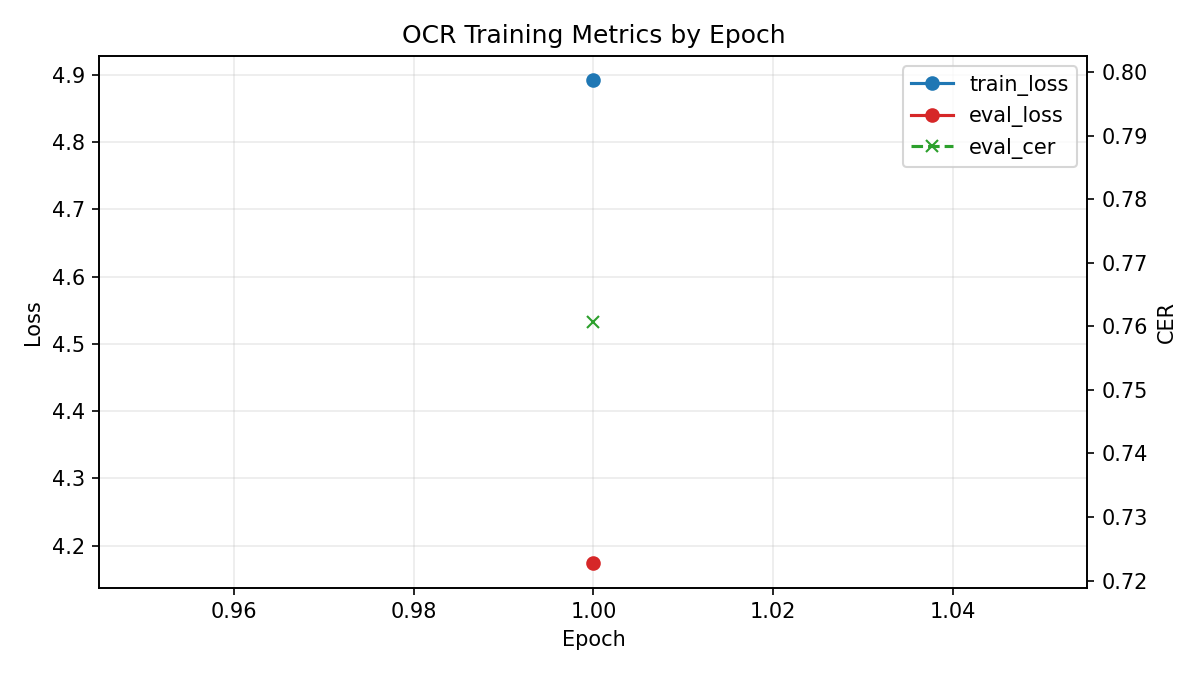

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'config': {'data_root': 'C:\\Users\\Francis BACKELAND\\.cache\\kagglehub\\datasets\\osamahosamabdellatif\\high-quality-invoice-images-for-ocr\\versions\\3',
  'output_dir': 'D:\\Projet\\scanned_images_classifier\\notebooks\\artifacts\\doc_understanding_ocr_cpu',
  'model_name': 'microsoft/trocr-small-printed',
  'train_csvs': ('outputs/batch1_train_split.csv',),
  'eval_csv': 'outputs/batch1_test_split.csv',
  'image_subdirs_train': ('.',),
  'image_subdir_eval': '.',
  'max_train_samples': 0,
  'max_eval_samples': 0,
  'max_target_length': 256,
  'image_size': 768,
  'use_grayscale': True,
  'learning_rate': 3e-05,
  'train_epochs': 1,
  'per_device_train_batch_size': 2,
  'per_device_eval_batch_size': 2,
  'random_seed': 3407,
  'lr_scheduler_type': 'cosine',
  'early_stopping_patience': 2,
  'early_stopping_threshold': 0.0,
  'metric_for_best_model': 'eval_cer',
  'greater_is_better': False,
  'allow_long_training': False,
  'require_supervised_eval': True,
  'allow_unlabeled_eval'

In [5]:
# Preset principal: split batch_1 (70/30) for supervised train/validation
MODEL_NAME = "microsoft/trocr-small-printed"
EPOCHS = 1
ALLOW_LONG_TRAINING = False  # passer a True uniquement si EPOCHS > 3 est intentionnel
MAX_TRAIN_SAMPLES = 0  # <=0 => tout le train batch_1
MAX_EVAL_SAMPLES = 0   # <=0 => all batch_1 test split (supervised)
TRAIN_BATCH_SIZE = 2
EVAL_BATCH_SIZE = 2
LEARNING_RATE = 3e-5
IMAGE_SIZE = 768
USE_GRAYSCALE = True
cfg = TrainConfig(
    data_root=data_root,
    output_dir=output_dir,
    model_name=MODEL_NAME,
    train_csvs=("outputs/batch1_train_split.csv",),
    eval_csv="outputs/batch1_test_split.csv",
    image_subdirs_train=(".",),
    image_subdir_eval=".",
    max_train_samples=MAX_TRAIN_SAMPLES,
    max_eval_samples=MAX_EVAL_SAMPLES,
    train_epochs=EPOCHS,
    allow_long_training=ALLOW_LONG_TRAINING,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    image_size=IMAGE_SIZE,
    use_grayscale=USE_GRAYSCALE,
    generation_num_beams=4,
    generation_length_penalty=1.0,
    generation_no_repeat_ngram_size=4,
    generation_repetition_penalty=1.15,
)
summary = run_training(cfg)
summary


plot_path: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\training_metrics.png
history_path: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\metrics_history.json


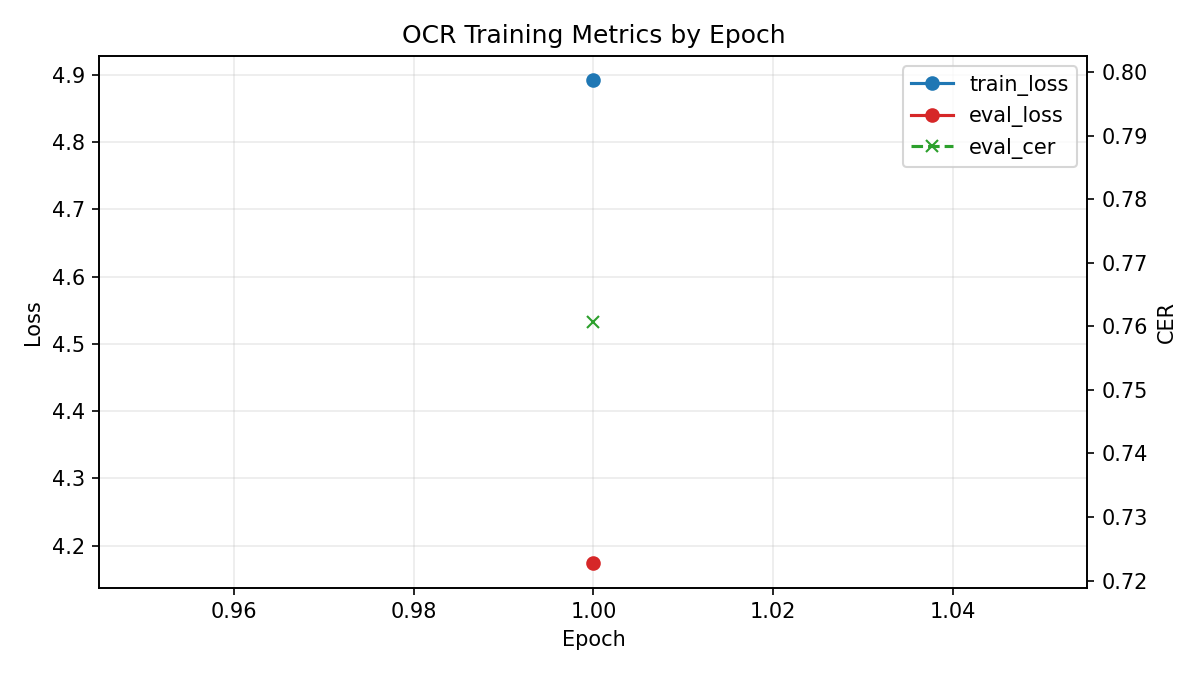

,epoch,loss
0,1.0,4.891996


,epoch,loss,cer,step
0,1.0,4.173537,0.760727,495


C:\Users\Francis BACKELAND\AppData\Local\Temp\ipykernel_18948\543699508.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [6]:
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt

plot_path = output_dir / "training_metrics.png"
history_path = output_dir / "metrics_history.json"

print("plot_path:", plot_path)
print("history_path:", history_path)
if plot_path.exists():
    display(Image(filename=str(plot_path)))
else:
    print("Plot not found yet.")

if history_path.exists():
    history = json.loads(history_path.read_text(encoding="utf-8"))
    train_df = pd.DataFrame(history.get("train", []))
    eval_df = pd.DataFrame(history.get("eval", []))
    display(train_df.tail())
    display(eval_df.tail())
    if eval_df.empty:
        print("Warning: no eval_loss logged yet. Check eval strategy / completed epoch.")

    plt.figure(figsize=(8,4))
    if not train_df.empty:
        plt.plot(train_df["epoch"], train_df["loss"], marker="o", label="train_loss")
    if not eval_df.empty:
        plt.plot(eval_df["epoch"], eval_df["loss"], marker="o", label="eval_loss")
    plt.title("Train vs Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()
else:
    print("metrics_history.json not found yet.")


In [7]:
# Cellule suivi tests + val loss
import json
import subprocess, sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

cmd = [
    sys.executable, "-m", "unittest", "discover",
    "-s", "tests/apps",
    "-p", "test_doc_understanding_cpu_gradio_smoke.py",
]
res = subprocess.run(cmd, capture_output=True, text=True, cwd=str(PROJECT_ROOT))
print("--- unit tests stdout ---")
print(res.stdout)
print("--- unit tests stderr ---")
print(res.stderr)
print("returncode:", res.returncode)

metrics_obj = globals().get("metrics")
if metrics_obj is not None:
    print("current_val_metrics:", metrics_obj)
else:
    eval_path = PROJECT_ROOT / "notebooks" / "artifacts" / "doc_understanding_ocr_cpu" / "eval_metrics.json"
    if eval_path.exists():
        payload = json.loads(eval_path.read_text(encoding="utf-8"))
        print("current_val_metrics:", payload.get("metrics", payload))
    else:
        print("current_val_metrics: not available yet")


--- unit tests stdout ---

--- unit tests stderr ---
..
----------------------------------------------------------------------
Ran 2 tests in 0.029s

OK

returncode: 0
current_val_metrics: {'mode': 'unlabeled', 'num_samples': 1, 'non_empty_rate': 1.0, 'avg_prediction_chars': 269.0, 'repetition_rate': 0.7410714285714286, 'total_prediction_chars': 269}


In [8]:
val_subset = val_image_paths[:100]
decode_grid = [
    {"num_beams": 4, "no_repeat_ngram_size": 4, "repetition_penalty": 1.15, "max_new_tokens": 192},
    {"num_beams": 4, "no_repeat_ngram_size": 4, "repetition_penalty": 1.20, "max_new_tokens": 192},
]

eval_runs = []
for grid in decode_grid:
    predictor_i = load_predictor(
        InferConfig(
            artifacts_dir=output_dir,
            max_new_tokens=grid["max_new_tokens"],
            image_size=768,
            use_grayscale=True,
            num_beams=grid["num_beams"],
            length_penalty=1.0,
            no_repeat_ngram_size=grid["no_repeat_ngram_size"],
            repetition_penalty=grid["repetition_penalty"],
            temperature=0.0,
        )
    )

    rows = []
    non_empty = 0
    total_chars = 0
    total_latency = 0.0
    for p in val_subset:
        out = predictor_i.predict(p)
        pred = out.get("prediction", "")
        lat = float(out.get("latency_ms", 0.0))
        rows.append({"image_path": str(p), "prediction": pred, "latency_ms": lat})
        non_empty += int(bool(pred.strip()))
        total_chars += len(pred)
        total_latency += lat

    n = max(len(rows), 1)
    metrics = {
        "num_samples": len(rows),
        "non_empty_rate": non_empty / n,
        "avg_prediction_chars": total_chars / n,
        "avg_latency_ms": total_latency / n,
    }
    eval_runs.append({"decode": grid, "metrics": metrics, "sample_predictions": rows[:5]})

# Priorite: texte non vide, puis latence plus faible
best_run = sorted(
    eval_runs,
    key=lambda x: (-x["metrics"]["non_empty_rate"], x["metrics"]["avg_latency_ms"]),
)[0]
best_decode = best_run["decode"]

predictor = load_predictor(
    InferConfig(
        artifacts_dir=output_dir,
        max_new_tokens=best_decode["max_new_tokens"],
        image_size=768,
        use_grayscale=True,
        num_beams=best_decode["num_beams"],
        length_penalty=1.0,
        no_repeat_ngram_size=best_decode["no_repeat_ngram_size"],
        repetition_penalty=best_decode["repetition_penalty"],
        temperature=0.0,
    )
)
best_run



Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

{'decode': {'num_beams': 4,
  'no_repeat_ngram_size': 4,
  'repetition_penalty': 1.15,
  'max_new_tokens': 192},
 'metrics': {'num_samples': 100,
  'non_empty_rate': 1.0,
  'avg_prediction_chars': 196.43,
  'avg_latency_ms': 384590.1175500002},
 'sample_predictions': [{'image_path': 'C:\\Users\\Francis BACKELAND\\.cache\\kagglehub\\datasets\\osamahosamabdellatif\\high-quality-invoice-images-for-ocr\\versions\\3\\batch_2\\batch_2\\batch2_1\\batch2-0001.jpg',
   'prediction': 'Invoice no: 07/17/2013 Seller: Client: Wilson-Ort: Harris and Sons Suite 875 Tax Id: 938-97 Tax IBAN: GBSZJZZIRKINKIUMEDERSONING No. Description Qty UM Net worth VAT [%] Gross worth 10% 1 0,00',
   'latency_ms': 323224.878},
  {'image_path': 'C:\\Users\\Francis BACKELAND\\.cache\\kagglehub\\datasets\\osamahosamabdellatif\\high-quality-invoice-images-for-ocr\\versions\\3\\batch_2\\batch_2\\batch2_1\\batch2-0002.jpg',
   'prediction': "Invoice no: 51889 Date of issue: 04/22/2020 Seller: Client: Lewis and Sons, Jackso

In [9]:
metrics_payload = {
    "mode": "unlabeled_batch2_validation",
    "best_decode": best_decode,
    "best_metrics": best_run["metrics"],
    "all_decode_runs": eval_runs,
    "num_val_images_sampled": len(val_subset),
    "checkpoint_selection": summary.get("checkpoint_selection"),
    "supervised_eval_enabled": summary.get("supervised_eval_enabled"),
}
metrics_path = output_dir / "eval_metrics.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2, ensure_ascii=False), encoding="utf-8")
print("saved:", metrics_path)
metrics_payload



saved: D:\Projet\scanned_images_classifier\notebooks\artifacts\doc_understanding_ocr_cpu\eval_metrics.json


{'mode': 'unlabeled_batch2_validation',
 'best_decode': {'num_beams': 4,
  'no_repeat_ngram_size': 4,
  'repetition_penalty': 1.15,
  'max_new_tokens': 192},
 'best_metrics': {'num_samples': 100,
  'non_empty_rate': 1.0,
  'avg_prediction_chars': 196.43,
  'avg_latency_ms': 384590.1175500002},
 'all_decode_runs': [{'decode': {'num_beams': 4,
    'no_repeat_ngram_size': 4,
    'repetition_penalty': 1.15,
    'max_new_tokens': 192},
   'metrics': {'num_samples': 100,
    'non_empty_rate': 1.0,
    'avg_prediction_chars': 196.43,
    'avg_latency_ms': 384590.1175500002},
   'sample_predictions': [{'image_path': 'C:\\Users\\Francis BACKELAND\\.cache\\kagglehub\\datasets\\osamahosamabdellatif\\high-quality-invoice-images-for-ocr\\versions\\3\\batch_2\\batch_2\\batch2_1\\batch2-0001.jpg',
     'prediction': 'Invoice no: 07/17/2013 Seller: Client: Wilson-Ort: Harris and Sons Suite 875 Tax Id: 938-97 Tax IBAN: GBSZJZZIRKINKIUMEDERSONING No. Description Qty UM Net worth VAT [%] Gross worth 10% 

In [10]:
img_eval = data_root / "batch_1/batch_1/batch1_1/batch1-0001.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

{'prediction': 'Invoice no: 07/17/2013 Seller: Client: Johnson and Sons 898 Roberts Suite 364 North Apt: 975 Tax Id: 938-97 Tax IBAN: GBIBAN: GB487 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1,00 each 4,00 each 19,99 10% 12,00 each 25,99 10% 1 0',
 'extracted_text': 'Invoice no: 07/17/2013 Seller: Client: Johnson and Sons 898 Roberts Suite 364 North Apt: 975 Tax Id: 938-97 Tax IBAN: GBIBAN: GB487 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1,00 each 4,00 each 19,99 10% 12,00 each 25,99 10% 1 0',
 'normalized_output': 'Invoice no: 07/17/2013 Seller: Client: Johnson and Sons 898 Roberts Suite 364 North Apt: 975 Tax Id: 938-97 Tax IBAN: GBIBAN: GB487 ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1,00 each 4,00 each 19,99 10% 12,00 each 25,99 10% 1 0',
 'raw_output': 'Invoice no: 07/17/2013 Seller: Client: Johnson and Sons 898 Roberts Suite 364 North Apt: 975 Tax Id: 938-97 Tax IBAN: GBIBAN: GB487 ITEMS No. Description Qty UM Net worth VAT [%] Gr

In [11]:
# Test inference sur une image batch_2
batch2_image = data_root / "batch_2/batch_2/batch2_1/batch2-0001.jpg"
result_batch2 = predictor.predict(batch2_image)
result_batch2

Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

{'prediction': 'Invoice no: 07/17/2013 Seller: Client: Wilson-Ort: Harris and Sons Suite 875 Tax Id: 938-97 Tax IBAN: GBSZJZZIRKINKIUMEDERSONING No. Description Qty UM Net worth VAT [%] Gross worth 10% 1 0,00',
 'extracted_text': 'Invoice no: 07/17/2013 Seller: Client: Wilson-Ort: Harris and Sons Suite 875 Tax Id: 938-97 Tax IBAN: GBSZJZZIRKINKIUMEDERSONING No. Description Qty UM Net worth VAT [%] Gross worth 10% 1 0,00',
 'normalized_output': 'Invoice no: 07/17/2013 Seller: Client: Wilson-Ort: Harris and Sons Suite 875 Tax Id: 938-97 Tax IBAN: GBSZJZZIRKINKIUMEDERSONING No. Description Qty UM Net worth VAT [%] Gross worth 10% 1 0,00',
 'raw_output': 'Invoice no: 07/17/2013 Seller: Client: Wilson-Ort: Harris and Sons Suite 875 Tax Id: 938-97 Tax IBAN: GBSZJZZIRKINKIUMEDERSONING No. Description Qty UM Net worth VAT [%] Gross worth 10% 1 0,00',
 'latency_ms': 365096.629,
 'segmentation_strategy': 'full_page_fallback',
 'used_full_page_fallback': True,
 'fallback_reason': 'max_total_chars

## Test A/B

In [12]:
img_eval = data_root / "tests_AB/batch3-0501.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

{'prediction': 'Invoice no: 07/17/2012 Seller: Client: Williams and Sons and Sons Suite 875 Tax Id: 938-97 Tax IBAN: GBSZJZZINKINKIQU6 ITEMS No. Description Qty UM Net worth VAT [%]',
 'extracted_text': 'Invoice no: 07/17/2012 Seller: Client: Williams and Sons and Sons Suite 875 Tax Id: 938-97 Tax IBAN: GBSZJZZINKINKIQU6 ITEMS No. Description Qty UM Net worth VAT [%]',
 'normalized_output': 'Invoice no: 07/17/2012 Seller: Client: Williams and Sons and Sons Suite 875 Tax Id: 938-97 Tax IBAN: GBSZJZZINKINKIQU6 ITEMS No. Description Qty UM Net worth VAT [%]',
 'raw_output': 'Invoice no: 07/17/2012 Seller: Client: Williams and Sons and Sons Suite 875 Tax Id: 938-97 Tax IBAN: GBSZJZZINKINKIQU6 ITEMS No. Description Qty UM Net worth VAT [%]',
 'latency_ms': 414359.563,
 'segmentation_strategy': 'full_page_fallback',
 'used_full_page_fallback': True,
 'fallback_reason': 'max_total_chars_exceeded',
 'crop_count': 1,
 'original_crop_count': 1,
 'deduplicated_crop_count': 1,
 'duplicate_crop_cou

In [13]:
img_eval = data_root / "tests_AB/facture_hors_corpus.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

{'prediction': 'Invoice no: 07/17/2013 Date of issue: Client: Johnson, Anderson and Smith and Sons 575 Tax Id: 945-9897 Tax IBAN: GBSZJZINKINKIUMED ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1,00 each 13,00 each 19,00 each 25,00 each 19,99 10% 65,00 each 12,00 each 29,99 10% 16,00 each 21,00 10% 49,00 each 19,95 10% 1',
 'extracted_text': 'Invoice no: 07/17/2013 Date of issue: Client: Johnson, Anderson and Smith and Sons 575 Tax Id: 945-9897 Tax IBAN: GBSZJZINKINKIUMED ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1,00 each 13,00 each 19,00 each 25,00 each 19,99 10% 65,00 each 12,00 each 29,99 10% 16,00 each 21,00 10% 49,00 each 19,95 10% 1',
 'normalized_output': 'Invoice no: 07/17/2013 Date of issue: Client: Johnson, Anderson and Smith and Sons 575 Tax Id: 945-9897 Tax IBAN: GBSZJZINKINKIUMED ITEMS No. Description Qty UM Net worth VAT [%] Gross worth 1,00 each 13,00 each 19,00 each 25,00 each 19,99 10% 65,00 each 12,00 each 29,99 10% 16,00 each 21,00 10% 

In [14]:
img_eval = data_root / "tests_AB/avril2025auchan-local1704202519042029S0C0epagny-1.jpg"
predictor.predict(img_eval)

Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=192) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'prediction': 'Invoice of issue: 07/25/2016 Seller: Client: Sons and Sons and Sons Suite 875 Tax Id: 964 Tax IBAN: 945-97 ITEMS No. Description Qty UM Net worth VAT [%]',
 'extracted_text': 'Invoice of issue: 07/25/2016 Seller: Client: Sons and Sons and Sons Suite 875 Tax Id: 964 Tax IBAN: 945-97 ITEMS No. Description Qty UM Net worth VAT [%]',
 'normalized_output': 'Invoice of issue: 07/25/2016 Seller: Client: Sons and Sons and Sons Suite 875 Tax Id: 964 Tax IBAN: 945-97 ITEMS No. Description Qty UM Net worth VAT [%]',
 'raw_output': 'Invoice of issue: 07/25/2016 Seller: Client: Sons and Sons and Sons Suite 875 Tax Id: 964 Tax IBAN: 945-97 ITEMS No. Description Qty UM Net worth VAT [%]',
 'latency_ms': 108274.787,
 'segmentation_strategy': 'full_page_fallback',
 'used_full_page_fallback': True,
 'fallback_reason': 'max_invoice_markers_per_page_exceeded',
 'crop_count': 1,
 'original_crop_count': 1,
 'deduplicated_crop_count': 1,
 'duplicate_crop_count': 0,
 'segment_count': 1,
 'dedu

## Lancer Gradio avec ce modele

```bash
python src/apps/doc_understanding_cpu_gradio.py --model-dir notebooks/artifacts/doc_understanding_ocr_cpu/model --model-meta-path notebooks/artifacts/doc_understanding_ocr_cpu/model_meta.json --host 127.0.0.1 --port 7862
```

Conseil test decode: comparer `num_beams=4` et `num_beams=6`, puis `no_repeat_ngram_size=3/4` et `repetition_penalty=1.1`.
